In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/sales_project.db")

In [4]:
# map the rank of each purchase within each customer based on the total price of the purchase

query = """
    SELECT
        Customer_ID,
        DATE(Purchase_Date) AS Purchase_Date,
        Product_Name,
        Total_Price,

        ROW_NUMBER() OVER (
            PARTITION BY Customer_ID
            ORDER BY Total_Price DESC
        ) AS rank_within_customer
    FROM Transaction_Records
    ORDER BY Customer_ID, rank_within_customer
"""
df_q1 = pd.read_sql_query(query, conn)
print(df_q1)

    Customer_ID Purchase_Date Product_Name  Total_Price  rank_within_customer
0    Customer_1    2022-07-28    Product_6          195                     1
1    Customer_1    2023-11-24    Product_8          169                     2
2    Customer_1    2022-03-11    Product_2          126                     3
3    Customer_1    2023-04-15    Product_7           94                     4
4    Customer_1    2024-12-26    Product_1           78                     5
..          ...           ...          ...          ...                   ...
223  Customer_9    2024-01-05    Product_3           68                     9
224  Customer_9    2022-03-29    Product_6           62                    10
225  Customer_9    2022-08-06    Product_9           32                    11
226  Customer_9    2024-06-14    Product_3           27                    12
227  Customer_9    2022-09-13   Product_10           25                    13

[228 rows x 5 columns]


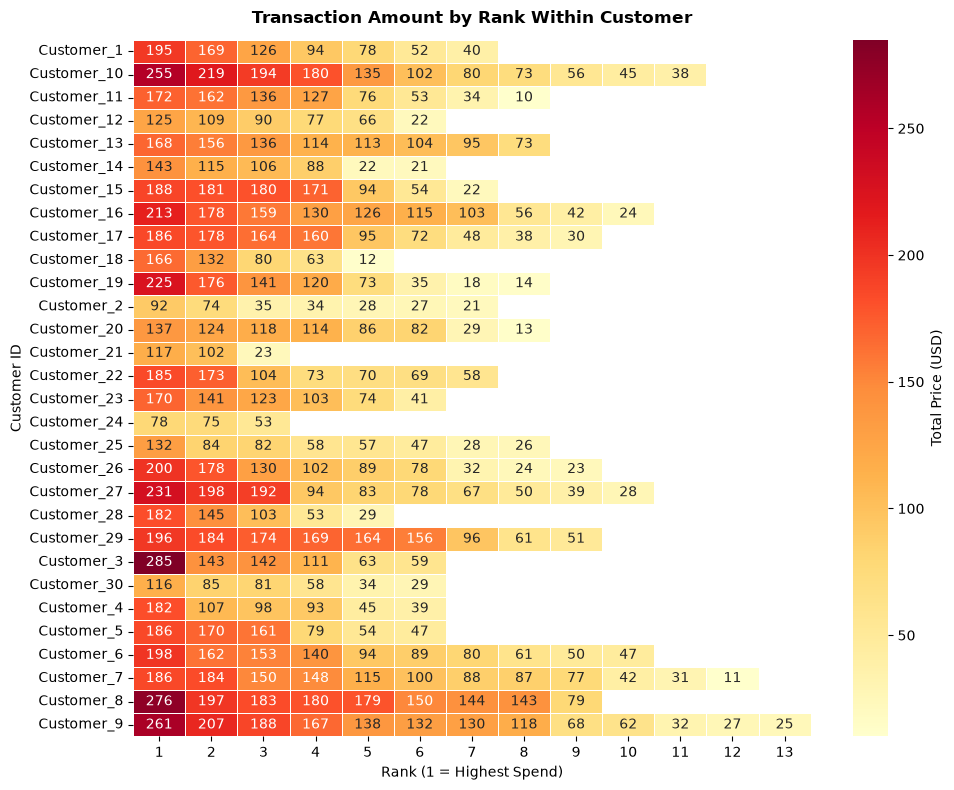

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# display a heatmap of the total price of each purchase by rank within each customer
# multi-purchase customers only

multi = df_q1.groupby("Customer_ID").filter(lambda x: len(x) > 1)
pivot = multi.pivot(
    index="Customer_ID", columns="rank_within_customer", values="Total_Price"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Total Price (USD)"},
)
ax.set_title("Transaction Amount by Rank Within Customer", fontweight="bold", pad=12)
ax.set_xlabel("Rank (1 = Highest Spend)")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.savefig("../images/rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Monthly sales and percentage change from the previous month

query = """
    WITH monthly_sales AS (
        SELECT
            strftime('%Y-%m', Purchase_Date) AS month,
            ROUND(SUM(Total_Price), 2) AS total_sales
        FROM Transaction_Records
        GROUP BY month
    )
    SELECT
        month,
        total_sales,
        LAG(total_sales) OVER (
            ORDER BY month
        ) AS previous_month_sales,
        ROUND(
            100 * (total_sales - LAG(total_sales) OVER (ORDER BY month)) / LAG(total_sales) OVER (ORDER BY month),
            2
        ) AS percentage_change
    FROM monthly_sales
    ORDER BY month
"""
df_q2 = pd.read_sql_query(query, conn)
print(df_q2)

      month  total_sales  previous_month_sales  percentage_change
0   2022-01        581.0                   NaN                NaN
1   2022-02        906.0                 581.0              55.94
2   2022-03        825.0                 906.0              -8.94
3   2022-04        758.0                 825.0              -8.12
4   2022-05       1114.0                 758.0              46.97
5   2022-06        821.0                1114.0             -26.30
6   2022-07        866.0                 821.0               5.48
7   2022-08        450.0                 866.0             -48.04
8   2022-09        537.0                 450.0              19.33
9   2022-10        526.0                 537.0              -2.05
10  2022-11        615.0                 526.0              16.92
11  2022-12        518.0                 615.0             -15.77
12  2023-01       1011.0                 518.0              95.17
13  2023-02        447.0                1011.0             -55.79
14  2023-0

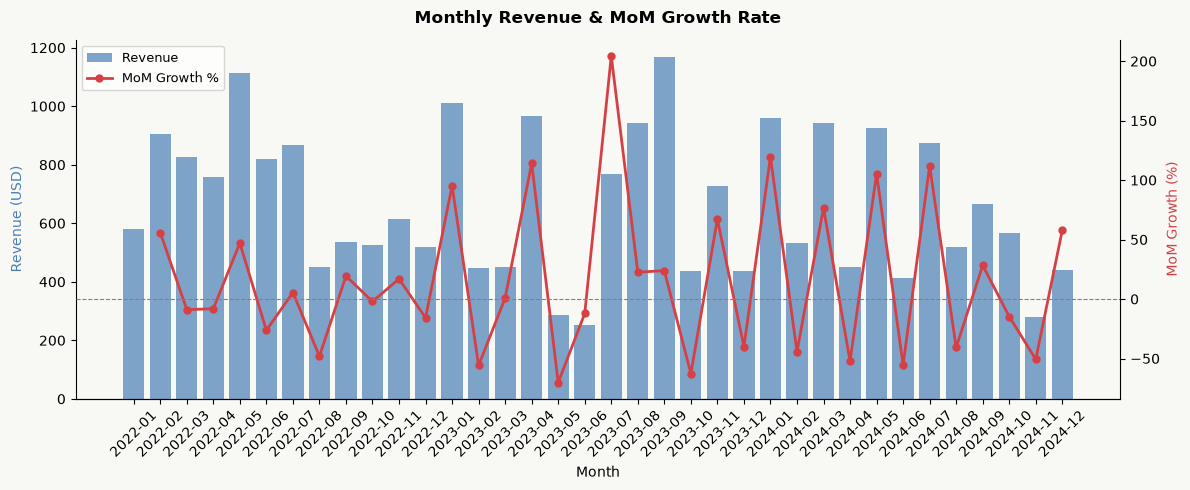

In [7]:
# Create a bar chart for monthly sales and a line chart for percentage change

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#F8F8F5")
ax1.set_facecolor("#F8F8F5")


ax1.bar(
    df_q2["month"], df_q2["total_sales"], color="#4A7FB5", alpha=0.7, label="Revenue"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (USD)", color="#4A7FB5")
ax1.tick_params(axis="x", rotation=45)
ax1.spines[["top", "right"]].set_visible(False)

# MoM growth rate line chart
ax2 = ax1.twinx()
ax2.plot(
    df_q2["month"],
    df_q2["percentage_change"],
    color="#D64045",
    linewidth=2,
    marker="o",
    markersize=5,
    label="MoM Growth %",
)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_ylabel("MoM Growth (%)", color="#D64045")
ax2.spines[["top", "left"]].set_visible(False)

ax1.set_title("Monthly Revenue & MoM Growth Rate", fontweight="bold", pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(
    "../images/mom_growth.png", dpi=150, bbox_inches="tight", facecolor="#F8F8F5"
)
plt.show()

In [8]:
# RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior

query = """
    WITH rfm AS (
        SELECT
            Customer_ID,
            CAST(JULIANDAY('2024-12-31') - JULIANDAY(MAX(Purchase_Date)) AS INT) AS recency_days,
            COUNT(*) AS frequency,
            ROUND(AVG(Total_Price), 2) AS monetary_value
        FROM Transaction_Records
        WHERE Order_Completion_Status = 'Completed'
        GROUP BY Customer_ID
    )
    SELECT
        Customer_ID,
        recency_days,
        frequency,
        monetary_value,
        CASE    WHEN recency_days <= 90 THEN 3
                WHEN recency_days <= 180 THEN 2
                ELSE 1
        END AS recency_score,
        CASE    WHEN frequency >= 5 THEN 3
                WHEN frequency >= 3 THEN 2
                ELSE 1
        END AS frequency_score,
        CASE    WHEN monetary_value >= 500 THEN 3
                WHEN monetary_value >= 200 THEN 2
                ELSE 1
        END AS monetary_score
    FROM rfm
    ORDER BY monetary_value DESC
"""
df = pd.read_sql_query(query, conn)
print(df)

    Customer_ID  recency_days  frequency  monetary_value  recency_score  \
0    Customer_8          1045          1          276.00              1   
1    Customer_9           469          3          189.00              1   
2   Customer_11           394          1          172.00              1   
3   Customer_28           360          2          163.50              1   
4   Customer_13           863          2          162.00              1   
5   Customer_17           158          3          153.00              2   
6   Customer_29           687          4          148.75              1   
7   Customer_10           454          4          135.50              1   
8    Customer_5           300          3          128.33              1   
9   Customer_26           117          5          126.80              2   
10  Customer_20            99          2          116.00              2   
11   Customer_4            22          3          111.33              3   
12  Customer_16          

In [9]:
# Identify high-value customers who have not made a purchase in the last 6 months and are in the top 30% of total spending

query = """
    WITH customer_stats AS (
        SELECT
            Customer_ID,
            ROUND(SUM(Total_Price), 2) AS total_spent,
            MAX(Purchase_Date) AS last_purchase_date,
            CAST(JULIANDAY('2024-12-31') - JULIANDAY(MAX(Purchase_Date)) AS INT) AS days_since_last
        FROM Transaction_Records
        WHERE Order_Completion_Status = 'Completed'
        GROUP BY Customer_ID
    ),
    ranked AS (
        SELECT *,
            NTILE(10) OVER (ORDER BY total_spent DESC) AS spent_decile
        FROM customer_stats
    )
    SELECT
        Customer_ID,
        total_spent,
        last_purchase_date,
        days_since_last,
        spent_decile,
        '!' AS alert
    FROM ranked
    WHERE spent_decile <= 3 AND days_since_last > 180
    ORDER BY total_spent DESC
"""
df_alerts = pd.read_sql_query(query, conn)
print(df_alerts)

   Customer_ID  total_spent          last_purchase_date  days_since_last  \
0  Customer_29        595.0         2023-02-12 02:34:00              687   
1   Customer_9        567.0         2023-09-18 13:17:01              469   
2  Customer_16        543.0         2023-09-22 12:58:18              465   
3  Customer_10        542.0         2023-10-03 07:45:23              454   
4  Customer_27        487.0  2022-05-29 05:41:57.995000              946   
5  Customer_19        419.0         2023-08-06 11:23:27              512   

   spent_decile alert  
0             1     !  
1             1     !  
2             2     !  
3             2     !  
4             2     !  
5             3     !  
